In [1]:
from tensorflow.keras.utils import to_categorical
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import numpy as np

%matplotlib inline
seed = 0
np.random.seed(seed)
import tensorflow as tf

tf.random.set_seed(seed)
import os

os.environ['PATH'] = os.environ['XILINX_VITIS'] + '/bin:' + os.environ['PATH']
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' 

2026-07-26 16:27:30.704137: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-07-26 16:27:30.729353: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-26 16:27:30.729377: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-26 16:27:30.730084: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-07-26 16:27:30.734181: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-07-26 16:27:30.734706: I tensorflow/core/platform/cpu_feature_guard.cc:1

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

2026-07-26 16:27:31.313340: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [2]:
X_train_val = np.load('X_train_val.npy')
X_test = np.load('X_test.npy')
y_train_val = np.load('y_train_val.npy')
y_test = np.load('y_test.npy')
classes = np.load('classes.npy', allow_pickle=True)

In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l1
from callbacks import all_callbacks
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score

In [4]:
model = Sequential()

model.add(Dense(64, input_shape=(8,), name='fc1', kernel_initializer='lecun_uniform', kernel_regularizer=l1(0.001)))
model.add(BatchNormalization())
model.add(Activation(activation='relu', name='relu1'))
model.add(Dropout(0.2))
model.add(Dense(32, name='fc2', kernel_initializer='lecun_uniform', kernel_regularizer=l1(0.001)))
model.add(Activation(activation='relu', name='relu2'))
model.add(Dropout(0.2))

model.add(Dense(1, name='output', kernel_initializer='lecun_uniform', kernel_regularizer=l1(0.001)))

model.add(Activation(activation='sigmoid', name='sigmoid'))

In [5]:
from tensorflow_model_optimization.python.core.sparsity.keras import prune, pruning_callbacks, pruning_schedule
from tensorflow_model_optimization.sparsity.keras import strip_pruning
import tensorflow_model_optimization as tfmot

NSTEPS = int(np.ceil(X_train_val.shape[0] / 32))

pruning_params = {
    'pruning_schedule':tfmot.sparsity.keras.PolynomialDecay(
    initial_sparsity=0.0,
    final_sparsity=0.5,
    begin_step=NSTEPS * 2,
    end_step=NSTEPS * 15,
    frequency=NSTEPS)
}

model = prune.prune_low_magnitude(model, **pruning_params)

In [6]:
train = True
if train:
    adam = Adam(learning_rate=0.001)
 
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=30,
        restore_best_weights=True
    )

    weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train_val), y=y_train_val)
    class_weights_dict = dict(enumerate(weights))
    
    model.compile(optimizer=adam, loss='binary_crossentropy', metrics=['accuracy'])    
    
    hls_callbacks = all_callbacks(
        stop_patience=50,
        lr_factor=0.5,
        lr_patience=10,
        lr_epsilon=0.000001,
        lr_cooldown=2,
        lr_minimum=0.0000001,
        outputDir='pruned_model_1',
    )
    pruning_callback = tfmot.sparsity.keras.UpdatePruningStep()
    hls_callbacks.callbacks.append(early_stop)
    hls_callbacks.callbacks.append(pruning_callback)
    model.fit(
        X_train_val,
        y_train_val,
        batch_size=128,
        epochs=2000,
        validation_split=0.25,
        shuffle=True,
        callbacks=hls_callbacks.callbacks, 
        class_weight=class_weights_dict
    ) 
    model = strip_pruning(model)
else:
    from tensorflow.keras.models import load_model
    
    model = load_model('pruned_model_1/KERAS_check_best_model.keras')

y_keras = model.predict(X_test)
y_pred = (y_keras > 0.5).astype(int).ravel()

print("Final accuracy:", accuracy_score(y_test, y_pred))

Epoch 1/2000
1/4 [======>.......................] - ETA: 5s - loss: 1.0833 - accuracy: 0.5469
***callbacks***
saving losses to pruned_model_1/losses.log

Epoch 1: val_loss improved from inf to 1.02090, saving model to pruned_model_1/KERAS_check_best_model.h5

Epoch 1: val_loss improved from inf to 1.02090, saving model to pruned_model_1/KERAS_check_best_model_weights.h5

Epoch 1: saving model to pruned_model_1/KERAS_check_model_last.h5

Epoch 1: saving model to pruned_model_1/KERAS_check_model_last_weights.h5

***callbacks end***

4/4 [==============================] - 2s 75ms/step - loss: 1.0535 - accuracy: 0.5804 - val_loss: 1.0209 - val_accuracy: 0.7208 - lr: 0.0010
Epoch 2/2000
1/4 [======>.......................] - ETA: 0s - loss: 1.0515 - accuracy: 0.5234WARNING:tensorflow:Callback method `on_train_batch_end` is slow compared to the batch time (batch time: 0.0011s vs `on_train_batch_end` time: 0.0039s). Check your callbacks.

***callbacks***
saving losses to pruned_model_1/losses

/home/tvangos/.local/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(



Epoch 3: saving model to pruned_model_1/KERAS_check_model_last.h5

Epoch 3: saving model to pruned_model_1/KERAS_check_model_last_weights.h5

***callbacks end***

4/4 [==============================] - 0s 28ms/step - loss: 0.9867 - accuracy: 0.6804 - val_loss: 0.9626 - val_accuracy: 0.7987 - lr: 0.0010
Epoch 4/2000
1/4 [======>.......................] - ETA: 0s - loss: 1.0024 - accuracy: 0.6797
***callbacks***
saving losses to pruned_model_1/losses.log

Epoch 4: val_loss improved from 0.96258 to 0.93858, saving model to pruned_model_1/KERAS_check_best_model.h5

Epoch 4: val_loss improved from 0.96258 to 0.93858, saving model to pruned_model_1/KERAS_check_best_model_weights.h5

Epoch 4: saving model to pruned_model_1/KERAS_check_model_last.h5

Epoch 4: saving model to pruned_model_1/KERAS_check_model_last_weights.h5

***callbacks end***

4/4 [==============================] - 0s 28ms/step - loss: 0.9718 - accuracy: 0.6826 - val_loss: 0.9386 - val_accuracy: 0.8052 - lr: 0.0010
Epoch 5/2

In [7]:
import hls4ml

config = hls4ml.utils.config_from_keras_model(model, granularity='model', backend='Vitis')
config['Part'] = 'xcu250-figd2104-2L-e'
print("-----------------------------------")
print("Configuration")
#plotting.print_dict(config)
print("-----------------------------------")

config['Model']['ReuseFactor'] = 16
hls_model = hls4ml.converters.convert_from_keras_model(
    model, hls_config=config, backend='Vitis', output_dir='pruned_model_1/hls4ml_prj', part='xcu250-figd2104-2L-e'
)
hls_model.compile()
y_keras = model.predict(X_test)
y_hls = hls_model.predict(np.ascontiguousarray(X_test))

-----------------------------------
Configuration
-----------------------------------
5/5 [==============================] - 0s 759us/step


% of zeros = 0.5


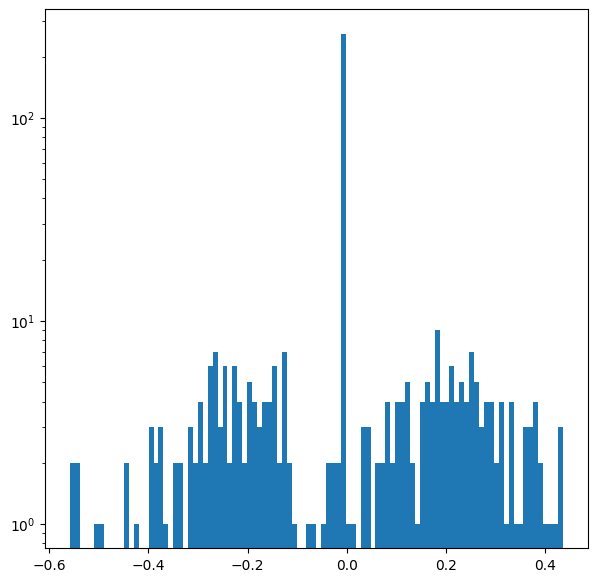

In [8]:
import plotting
import matplotlib.pyplot as plt

w = model.layers[0].weights[0].numpy()
h, b = np.histogram(w, bins=100)
plt.figure(figsize=(7, 7))
plt.bar(b[:-1], h, width=b[1] - b[0])
plt.semilogy()
print('% of zeros = {}'.format(np.sum(w == 0) / np.size(w)))

5/5 [==============================] - 0s 822us/step
Unpruned Model Accuracy: 78.57%
Pruned Model Accuracy:   74.68%
------------------------------
Accuracy Lost:           3.896%


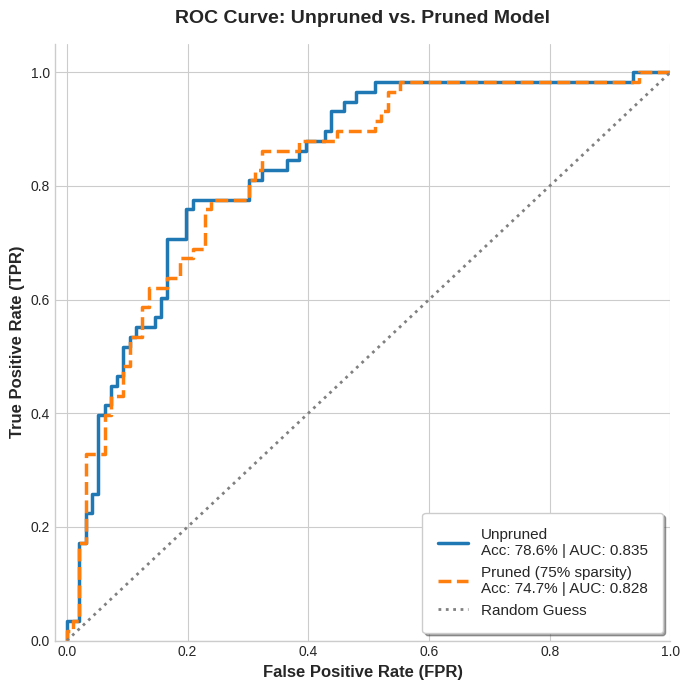

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.models import load_model
from sklearn.metrics import accuracy_score, roc_curve, auc

# Load the unpruned baseline model
model_ref = load_model('model_1/KERAS_check_best_model.h5')
y_ref = model_ref.predict(X_test)

# Load the pruned model 
with tfmot.sparsity.keras.prune_scope():
    model_pruned = load_model('pruned_model_1/KERAS_check_best_model.h5')
y_prune = model_pruned.predict(X_test)

# Calculate the standard accuracy for both models
# Convert probability outputs to binary class predictions
y_ref_classes = (np.array(y_ref).flatten() > 0.5).astype(int)
y_prune_classes = (np.array(y_prune).flatten() > 0.5).astype(int)

acc_unpruned = accuracy_score(y_test, y_ref_classes)
acc_pruned = accuracy_score(y_test, y_prune_classes)
acc_loss = acc_unpruned - acc_pruned

print(f"Unpruned Model Accuracy: {acc_unpruned * 100:.2f}%")
print(f"Pruned Model Accuracy:   {acc_pruned * 100:.2f}%")
print("-" * 30)
if acc_loss > 0:
    print(f"Accuracy Lost:           {acc_loss * 100:.3f}%")
else:
    print(f"Accuracy Improved by:    {abs(acc_loss) * 100:.3f}%")

# Calculate ROC and AUC for both models
fpr_ref, tpr_ref, _ = roc_curve(y_test, np.array(y_ref).flatten())
roc_auc_ref = auc(fpr_ref, tpr_ref)

fpr_prune, tpr_prune, _ = roc_curve(y_test, np.array(y_prune).flatten())
roc_auc_prune = auc(fpr_prune, tpr_prune)

# Draw the ROC Plot
plt.style.use('seaborn-v0_8-whitegrid') 
fig, ax = plt.subplots(figsize=(7, 7))

# Plot unpruned Model
ax.plot(fpr_ref, tpr_ref, color='#1f77b4', linewidth=2.5, 
        label=f"Unpruned\nAcc: {acc_unpruned*100:.1f}% | AUC: {roc_auc_ref:.3f}")

# Plot pruned Model 
ax.plot(fpr_prune, tpr_prune, color='#ff7f0e', linewidth=2.5, linestyle='--',
        label=f"Pruned (75% sparsity)\nAcc: {acc_pruned*100:.1f}% | AUC: {roc_auc_prune:.3f}")

# Plot Random Guess Baseline
ax.plot([0, 1], [0, 1], color='gray', linestyle=':', linewidth=2, label="Random Guess")

ax.set_xlabel("False Positive Rate (FPR)", fontsize=12, fontweight='bold')
ax.set_ylabel("True Positive Rate (TPR)", fontsize=12, fontweight='bold')
ax.set_title("ROC Curve: Unpruned vs. Pruned Model", fontsize=14, fontweight='bold', pad=15)
ax.set_xlim([-0.02, 1.0])
ax.set_ylim([0.0, 1.05])
ax.legend(loc="lower right", fontsize=11, frameon=True, shadow=True, borderpad=1)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [10]:
hls_model.build(csim=False)


****** vitis-run v2023.2 (64-bit)
  **** SW Build 4026344 on 2023-10-11-15:42:10
    ** Copyright 1986-2022 Xilinx, Inc. All Rights Reserved.
    ** Copyright 2022-2023 Advanced Micro Devices, Inc. All Rights Reserved.

INFO: [vitis-run 82-31] Launching vitis_hls: vitis_hls -nolog -run tcl -f /home/tvangos/Desktop/UTH/CPU_design/src/pruned_model_1/hls4ml_prj/build_prj.tcl -work_dir /home/tvangos/Desktop/UTH/CPU_design/src/pruned_model_1/hls4ml_prj

****** Vitis HLS - High-Level Synthesis from C, C++ and OpenCL v2023.2 (64-bit)
  **** SW Build 4023990 on Oct 11 2023
  **** IP Build 4028589 on Sat Oct 14 00:45:43 MDT 2023
  **** SharedData Build 4025554 on Tue Oct 10 17:18:54 MDT 2023
    ** Copyright 1986-2022 Xilinx, Inc. All Rights Reserved.
    ** Copyright 2022-2023 Advanced Micro Devices, Inc. All Rights Reserved.

source /tools/Xilinx/Vitis_HLS/2023.2/scripts/vitis_hls/hls.tcl -notrace
INFO: [HLS 200-10] Running '/tools/Xilinx/Vitis_HLS/2023.2/bin/unwrapped/lnx64.o/vitis_hls'
INF

{'CSynthesisReport': {'TargetClockPeriod': '5.00',
  'EstimatedClockPeriod': '3.480',
  'BestLatency': '56',
  'WorstLatency': '56',
  'IntervalMin': '16',
  'IntervalMax': '16',
  'BRAM_18K': '1',
  'DSP': '85',
  'FF': '15424',
  'LUT': '36329',
  'URAM': '0',
  'AvailableBRAM_18K': '5376',
  'AvailableDSP': '12288',
  'AvailableFF': '3456000',
  'AvailableLUT': '1728000',
  'AvailableURAM': '1280'}}

In [11]:
hls4ml.report.read_vivado_report('pruned_model_1/hls4ml_prj')

Found 1 solution(s) in pruned_model_1/hls4ml_prj/myproject_prj.
Reports for solution "solution1":

C simulation report not found.
SYNTHESIS REPORT:
== Vitis HLS Report for 'myproject'
* Date:           Sun Jul 26 16:28:51 2026

* Version:        2023.2 (Build 4023990 on Oct 11 2023)
* Project:        myproject_prj
* Solution:       solution1 (Vivado IP Flow Target)
* Product family: virtexuplus
* Target device:  xcu250-figd2104-2L-e


== Performance Estimates
+ Timing: 
    * Summary: 
    +--------+---------+----------+------------+
    |  Clock |  Target | Estimated| Uncertainty|
    +--------+---------+----------+------------+
    |ap_clk  |  5.00 ns|  3.480 ns|     1.35 ns|
    +--------+---------+----------+------------+

+ Latency: 
    * Summary: 
    +---------+---------+----------+----------+-----+-----+---------+
    |  Latency (cycles) |  Latency (absolute) |  Interval | Pipeline|
    |   min   |   max   |    min   |    max   | min | max |   Type  |
    +---------+---------+